In [4]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Convert percentage weight to decimal
holdings["weight_decimal"] = holdings["weight_pct"] / 100

# Sum all stock weights within each sector for each fund
sector_weights = (
    holdings.groupby(["amfi_code", "sector"])["weight_decimal"]
    .sum()
    .reset_index()
)

# Square each sector weight
sector_weights["weight_squared"] = sector_weights["weight_decimal"] ** 2

# Calculate HHI for each fund
sector_hhi = (
    sector_weights.groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="Sector_HHI")
    .sort_values("Sector_HHI", ascending=False)
)

# Add concentration level
def concentration_level(hhi):
    if hhi < 0.15:
        return "Low Concentration"
    elif hhi < 0.25:
        return "Moderate Concentration"
    else:
        return "High Concentration"

sector_hhi["concentration_level"] = sector_hhi["Sector_HHI"].apply(
    concentration_level
)

sector_hhi

,amfi_code,Sector_HHI,concentration_level
11,119092,0.296769,High Concentration
30,148569,0.254992,High Concentration
27,125498,0.253155,High Concentration
6,102887,0.251383,High Concentration
32,149323,0.241077,Moderate Concentration
21,120505,0.238695,Moderate Concentration
10,118635,0.237497,Moderate Concentration
18,119599,0.232361,Moderate Concentration
22,120506,0.231464,Moderate Concentration
1,100033,0.227647,Moderate Concentration


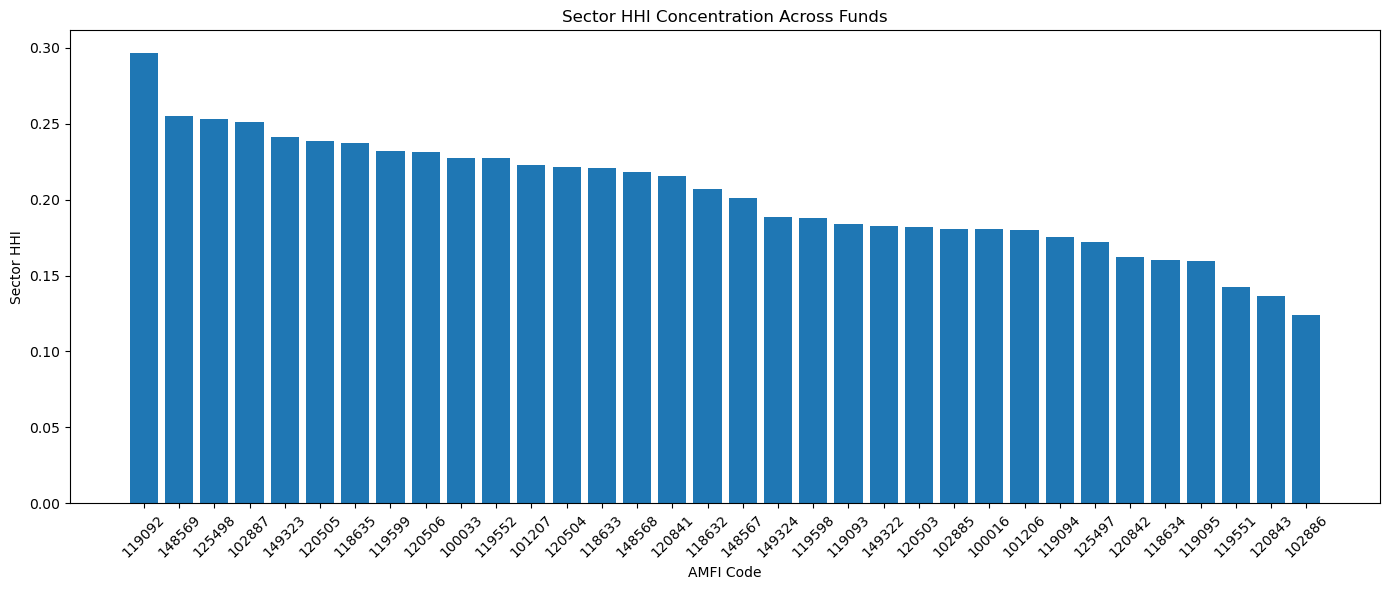

In [5]:
plt.figure(figsize=(14, 6))

plt.bar(
    sector_hhi["amfi_code"].astype(str),
    sector_hhi["Sector_HHI"]
)

plt.title("Sector HHI Concentration Across Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Sector HHI")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
sector_hhi.to_csv(
    "../data/processed/sector_hhi_analysis.csv",
    index=False
)